# 01 - Data loading and cleaning

This is the first stage in the project's pipeline. It reads Israel's raw GTFS file (the national export of public-transport schedules), converts the text tables into typed data frames, applies a small and explicit set of sanity filters, and attaches to every stop two coarse geographic labels: a region (North / Center / Jerusalem / South) and a metro (Tel Aviv / Haifa / Jerusalem / Beer Sheva / Periphery). Every other stage of the project - building the graph, centrality metrics, robustness - starts from the cleaned tables written here, so this notebook also produces a machine-readable cleaning report that records exactly how many rows each filter removed.

The guiding idea is that a network study is only as trustworthy as its node table. If a stop has a broken coordinate, or if the same `stop_id` shows up twice, the graph quietly gets a ghost node and every centrality value computed later is contaminated. So each filter here is written as its own step, counted, and reported.

**The research question this stage serves:** *what exactly is the node set of Israel's public-transport network, and what did we throw out to get there?*

### Input

- `israel-public-transportation/stops.txt` - one row per physical stop / station (id, name, latitude, longitude, location type, parent station).
- `israel-public-transportation/routes.txt` - one row per route, with `route_type` (3 = bus, 2 = rail, ...) and the operator's `agency_id`.
- `israel-public-transportation/trips.txt` - one row per scheduled vehicle trip; this is the service-volume table.
- `israel-public-transportation/agency.txt` - one row per operator.

All four files are tracked in the repository. This notebook does **not** touch `stop_times.txt` (816 MB, not tracked in git) - that file is only needed from notebook 02 onward.

### Output (all under `outputs/nb/01_data_preparation/`)

- `tables/stops_clean.csv` - the cleaned node table, plus the new `region` and `metro` columns.
- `tables/routes_clean.csv`, `tables/trips_clean.csv`, `tables/agencies_clean.csv` - pass-through copies with stable types, so later notebooks don't have to re-derive the parsing options.
- `tables/route_type_distribution.csv` - the number of routes and scheduled trips by GTFS mode.
- `tables/agency_trip_counts.csv` - scheduled trips per operator.
- `tables/data_cleaning_report.json` - the audit trail: row counts before and after each filter, region/metro breakdowns, and referential-integrity checks.
- `figures/*.png` - four descriptive figures.

### Dependencies

None. This is stage 01; it reads only the raw file.

## Setting up the working environment

The cell below is identical across all the project's notebooks. It does three things: (1) it defines `_ensure`, which pip-installs *only* the packages that are actually missing, so a repeat run costs nothing; (2) it locates the repository root by walking upward from the current directory looking for the `israel-public-transportation` folder, and clones the repo if we're on a fresh Google Colab machine; (3) it creates the shared `outputs/nb` folder. After this cell, `REPO`, `DATA`, and `OUT` are available and the working directory is the repository root, so every path in the notebook can be written relative to a known anchor.

In [27]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Libraries, stage folder, and tunable constants

This notebook owns the folder `outputs/nb/01_data_preparation/`, split into `tables/` and `figures/`. Nothing is ever written to `outputs/tables`, `outputs/figures`, or `outputs/rail`.

Two groups of constants are collected here so the reader can see and change every tunable parameter in one place:

- **`LAT_MIN/LAT_MAX/LON_MIN/LON_MAX`** - the bounding box a coordinate has to fall inside to be accepted as a real Israeli stop. The box is deliberately wide (Eilat is around 29.55 N, Metula around 33.28 N), so it catches only obviously broken values such as a `0,0` placeholder, not legitimate stops at the edge of the country.
- **`SAVE_TRIPS_CSV`** - `trips.txt` weighs about 28 MB and holds roughly 1.2 million rows; rewriting it as CSV is the slowest operation in this notebook (tens of seconds and 28 MB of disk). Set it to `False` if you only care about the stops table and the report.

In [28]:
# Third-party libraries used below. _ensure only installs what is missing.
_ensure("pandas", "numpy", "matplotlib")

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- This notebook's own output folder (stage 01) ---
STAGE = OUT / "01_data_preparation"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ---
LAT_MIN, LAT_MAX = 29.0, 34.0   # generous bounding box around Israel
LON_MIN, LON_MAX = 34.0, 36.0
SAVE_TRIPS_CSV = True           # writing trips_clean.csv costs ~28 MB and tens of seconds

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("GTFS folder :", DATA)
print("Stage folder:", STAGE)

GTFS folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\israel-public-transportation
Stage folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\01_data_preparation


## Displaying Hebrew labels correctly

All the stop names and operator names in the file are in Hebrew, and one of the figures below is a bar chart of operator names. Matplotlib draws glyphs in logical order (storage order) and doesn't apply the Unicode bidirectional algorithm, so Hebrew text comes out visually reversed. The cell below patches `matplotlib.text.Text.set_text` once, so every Hebrew string is converted to display order before drawing. Strings with no Hebrew characters pass through unchanged, and the patch is idempotent (running the cell again does no harm).

In [29]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## Loading the raw GTFS tables

GTFS files are plain comma-separated text, but three parsing decisions are important enough to state explicitly, because getting any of them wrong corrupts the ids the whole graph rests on:

1. **`dtype=str`** - GTFS ids are opaque strings, not numbers. If pandas infers integers, `"01"` and `"1"` collapse to the same value and the joins between `trips` and `routes` start matching the wrong rows. We keep everything as text and convert only the two coordinate columns, deliberately, later on.
2. **`keep_default_na=False`** - an empty GTFS field means *not supplied*, and some real stop names and descriptions in this file contain strings like `NA`. If we let pandas auto-convert those to `NaN`, we'd both invent missing data and destroy real names.
3. **`encoding="utf-8-sig"`** - the Israeli file ships with a UTF-8 byte-order mark (BOM). Without this setting, the first column of each file is read with an invisible BOM character glued to its name, and `df["stop_id"]` throws a `KeyError`.

We load all four tables into a dictionary of *raw* frames and leave them untouched, so any later row count can be compared against the source.

In [30]:
GTFS_FILES = {
    "stops":  "stops.txt",
    "routes": "routes.txt",
    "trips":  "trips.txt",
    "agency": "agency.txt",
}

def load_gtfs(name):
    """Load one GTFS table as raw text, with the three parsing decisions above."""
    path = DATA / GTFS_FILES[name]
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. The GTFS feed is tracked in the repository - "
            "check that the clone completed and that DATA points at the feed folder."
        )
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig")

raw = {name: load_gtfs(name) for name in GTFS_FILES}

for name, df in raw.items():
    print(f"{name:7s} rows={len(df):>9,d}  columns={list(df.columns)}")

raw["stops"].head(3)

stops   rows=   34,932  columns=['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'zone_id']
routes  rows=    7,792  columns=['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_color']
trips   rows=  420,133  columns=['route_id', 'service_id', 'trip_id', 'trip_headsign', 'direction_id', 'shape_id', 'wheelchair_accessible']
agency  rows=       37  columns=['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone', 'agency_fare_url']


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,zone_id
0,1,38831,בי''ס בר לב/בן יהודה,רחוב: בן יהודה 74 עיר: כפר סבא רציף: קומה:,32.183985,34.917554,0,,38831
1,2,38832,הרצל/צומת בילו,רחוב: הרצל עיר: קרית עקרון רציף: קומה:,31.869152,34.819641,0,,38832
2,3,38833,מרכז ראשונים/הנחשול,רחוב: הנחשול 30 עיר: ראשון לציון רציף: קומה:,31.984553,34.782828,0,,38833


## Cleaning the stops table, one auditable filter at a time

The stops table is the node table of the future graph, so it gets the most careful scrutiny. Four filters are applied one after another, and each records how many rows it removed into `cleaning_steps`, which is later serialized to the JSON report:

1. **Unparseable coordinates.** `stop_lat` / `stop_lon` are converted with `errors="coerce"`, so an empty string or any non-numeric junk becomes `NaN`, and those rows are dropped. A stop with no location can't be placed in a spatial graph at all.
2. **Latitude inside the bounding box** (`29 < lat < 34`). Catches `0.0` placeholders and digit-swap typos.
3. **Longitude inside the bounding box** (`34 < lon < 36`). Same reasoning.
4. **Duplicate `stop_id`.** This filter is an addition to the original cleaning script. `stop_id` is the node key in every later stage; if it weren't unique, a merge would duplicate rows and inflate the degree of the duplicated node. Keeping the first occurrence makes the guarantee explicit instead of assumed.

**An honest note up front:** in the version of the file shipped with this repository, filters 1-4 all remove **zero** rows - the coordinates are intact and in range, and `stop_id` is already unique. That's a good result, not a wasted step: the numbers printed below are the evidence for the claim, and the same code protects the pipeline if the file is ever refreshed with a dirtier export.

Note also what we deliberately don't filter: rows with `location_type = 1` are *parent stations* (parent containers), not boardable platforms. They stay in the table here, and the report counts them, so the graph-building notebook can decide how to handle parent/child stations when all the information is in front of it.

In [31]:
cleaning_steps = []

def record(step, before, after, note):
    """Log one cleaning filter so the report can state exactly what was dropped."""
    cleaning_steps.append({
        "step": step,
        "rows_before": int(before),
        "rows_after": int(after),
        "rows_dropped": int(before - after),
        "note": note,
    })
    print(f"{step:26s} {before:>7,d} -> {after:>7,d}   dropped {before - after:>6,d}   {note}")

stops = raw["stops"].copy()

# 1. Coordinates must be numeric. Empty strings and junk become NaN and are dropped.
stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
before = len(stops)
stops = stops.dropna(subset=["stop_lat", "stop_lon"])
record("numeric coordinates", before, len(stops), "stop_lat/stop_lon parse as numbers")

# 2. Latitude inside the Israel bounding box.
before = len(stops)
stops = stops[(stops["stop_lat"] > LAT_MIN) & (stops["stop_lat"] < LAT_MAX)]
record("latitude in range", before, len(stops), f"{LAT_MIN} < lat < {LAT_MAX}")

# 3. Longitude inside the Israel bounding box.
before = len(stops)
stops = stops[(stops["stop_lon"] > LON_MIN) & (stops["stop_lon"] < LON_MAX)]
record("longitude in range", before, len(stops), f"{LON_MIN} < lon < {LON_MAX}")

# 4. stop_id is the node key of the graph - it has to be unique.
before = len(stops)
stops = stops.drop_duplicates(subset=["stop_id"], keep="first")
record("unique stop_id", before, len(stops), "stop_id is the graph node key")

stops = stops.reset_index(drop=True)
kept = 100.0 * len(stops) / len(raw["stops"])
print()
print(f"clean stops: {len(stops):,d} of {len(raw['stops']):,d} raw rows kept ({kept:.2f}%)")
print()
print("location_type breakdown of the clean table (0 = stop/platform, 1 = station):")
print(stops["location_type"].value_counts().to_string())

numeric coordinates         34,932 ->  34,932   dropped      0   stop_lat/stop_lon parse as numbers
latitude in range           34,932 ->  34,932   dropped      0   29.0 < lat < 34.0
longitude in range          34,932 ->  34,932   dropped      0   34.0 < lon < 36.0
unique stop_id              34,932 ->  34,932   dropped      0   stop_id is the graph node key

clean stops: 34,932 of 34,932 raw rows kept (100.00%)

location_type breakdown of the clean table (0 = stop/platform, 1 = station):
location_type
0    34734
1      198


## Sanity-checking the coordinates

Before trusting the bounding-box filter, it's worth looking at how the data actually spreads out: if the observed min and max sit comfortably *inside* the box, the filter is a guardrail and not a mechanism that quietly cut off part of the country. The output below shows the extreme values and the corner stops, which are easy to verify against a map (the southernmost extreme should be Eilat, and the northernmost the Upper Galilee).

In [32]:
print(f"latitude  range: {stops['stop_lat'].min():.5f} .. {stops['stop_lat'].max():.5f}   (box {LAT_MIN} .. {LAT_MAX})")
print(f"longitude range: {stops['stop_lon'].min():.5f} .. {stops['stop_lon'].max():.5f}   (box {LON_MIN} .. {LON_MAX})")
print()

extremes = pd.DataFrame([
    stops.loc[stops["stop_lat"].idxmin()],
    stops.loc[stops["stop_lat"].idxmax()],
    stops.loc[stops["stop_lon"].idxmin()],
    stops.loc[stops["stop_lon"].idxmax()],
])
extremes.index = ["southernmost", "northernmost", "westernmost", "easternmost"]
extremes[["stop_id", "stop_name", "stop_lat", "stop_lon"]]

latitude  range: 29.49311 .. 33.28220   (box 29.0 .. 34.0)
longitude range: 34.28467 .. 35.83911   (box 34.0 .. 36.0)



,stop_id,stop_name,stop_lat,stop_lon
southernmost,12510,מעבר גבול טאבה,29.493109,34.905113
northernmost,41692,מרכז מסחרי,33.282204,35.578985
westernmost,27064,כרם שלום מרכז,31.227769,34.284672
easternmost,20366,אלוני הבשן/מרכז,33.043421,35.839108


## Region and metro labels

Later stages compare centrality and robustness across parts of the country, so every stop needs a geographic label. The file supplies none - `stops.txt` has no administrative-district column - so we derive two labels from the coordinates alone.

**`region`** (first matching rule wins, an exact reproduction of the original `if/elif` chain):

| Order | Rule | Label |
|---|---|---|
| 1 | `31.70 <= lat <= 31.90` **and** `34.95 <= lon <= 35.30` | Jerusalem |
| 2 | `lat > 32.50` | North |
| 3 | `lat >= 31.55` | Center |
| 4 | otherwise | South |

**`metro`** - the first center whose disk contains the stop: Tel Aviv (30 km), Haifa (25 km), Jerusalem (20 km), Beer Sheva (25 km); everything else is classified as `Periphery`. The distances are great-circle (haversine) distances.

### Limitations - please read this before using the labels

**The region assignment is a crude latitude/longitude rule, not real administrative or statistical geography.** It knows nothing about district boundaries, municipal boundaries, the Green Line, topography, or travel time. Concretely:

- Regions 2/3/4 are pure latitude cuts, so they are horizontal strips across the country. A stop in the western Negev lowlands and a stop in the eastern Judean Desert at the same latitude get the same label, even though they belong to completely different transport realities.
- The Jerusalem region is a rectangle, so stops in the Jerusalem corridor just outside the box fall under "Center", and the rectangle is checked *first*, meaning it overrides the latitude strips wherever they disagree.
- The metro disks are circles around a single city-center point with hand-picked radii. A 30 km disk around Tel Aviv reaches well beyond the statistical Gush Dan in some directions and doesn't reach it in others.
- `region` and `metro` are computed independently and can contradict each other - a stop can be `region = Center` and `metro = Jerusalem` at the same time.

So the labels are fine for coarse descriptive grouping ("roughly how much of the network sits in the north?") and should **not** be presented as official regional statistics. The original script used Hebrew labels; they've been translated here to English (North / Center / Jerusalem / South, and Periphery for whatever isn't metropolitan) with no change to the threshold values.

One implementation note: the original code called a scalar haversine function inside `DataFrame.apply` once per stop, meaning roughly 35,000 Python-level function calls. The version below computes the same numbers vectorized with NumPy - identical results, in a fraction of the runtime. The cell also prints the distances between each pair of the four metro centers, to confirm the disks don't overlap; if there's no overlap, then "first match wins" and "nearest center wins" are the same rule, and the dictionary order carries no hidden bias.

In [33]:
# Metro centres: name -> (latitude, longitude, radius in km)
METRO_CENTERS = {
    "Tel Aviv":   (32.0853, 34.7818, 30),
    "Haifa":      (32.7940, 34.9896, 25),
    "Jerusalem":  (31.7683, 35.2137, 20),
    "Beer Sheva": (31.2518, 34.7913, 25),
}

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Accepts scalars or NumPy arrays."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(np.asarray(lat2) - np.asarray(lat1))
    dlam = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))

lat = stops["stop_lat"].to_numpy()
lon = stops["stop_lon"].to_numpy()

# --- Region: np.select evaluates conditions in order, exactly like if/elif/else ---
region_conditions = [
    (lat >= 31.70) & (lat <= 31.90) & (lon >= 34.95) & (lon <= 35.30),  # Jerusalem box
    lat > 32.50,                                                        # North
    lat >= 31.55,                                                       # Center
]
stops["region"] = np.select(region_conditions, ["Jerusalem", "North", "Center"], default="South")

# --- Metro: first centre whose disc contains the stop ---
metro_conditions, metro_names = [], []
for city, (clat, clon, radius) in METRO_CENTERS.items():
    metro_conditions.append(haversine_km(lat, lon, clat, clon) <= radius)
    metro_names.append(city)
stops["metro"] = np.select(metro_conditions, metro_names, default="Periphery")

# --- Do the metro discs overlap? If not, dictionary order is irrelevant. ---
print("metro disc overlap check")
items = list(METRO_CENTERS.items())
for i in range(len(items)):
    for j in range(i + 1, len(items)):
        a_name, (a_lat, a_lon, a_r) = items[i]
        b_name, (b_lat, b_lon, b_r) = items[j]
        d = float(haversine_km(a_lat, a_lon, b_lat, b_lon))
        verdict = "OVERLAP - order matters" if d < a_r + b_r else "disjoint"
        print(f"  {a_name:11s} - {b_name:11s}: {d:6.1f} km apart, radii sum {a_r + b_r:3d} km -> {verdict}")

print()
print("stops per region")
print(stops["region"].value_counts().to_string())
print()
print("stops per metro")
print(stops["metro"].value_counts().to_string())
print()
print("region x metro cross-tabulation (they are computed independently and can disagree)")
pd.crosstab(stops["region"], stops["metro"])

metro disc overlap check
  Tel Aviv    - Haifa      :   81.2 km apart, radii sum  55 km -> disjoint
  Tel Aviv    - Jerusalem  :   53.9 km apart, radii sum  50 km -> disjoint
  Tel Aviv    - Beer Sheva :   92.7 km apart, radii sum  55 km -> disjoint
  Haifa       - Jerusalem  :  116.0 km apart, radii sum  45 km -> disjoint
  Haifa       - Beer Sheva :  172.5 km apart, radii sum  50 km -> disjoint
  Jerusalem   - Beer Sheva :   70.0 km apart, radii sum  45 km -> disjoint

stops per region
region
Center       14947
North        11507
South         4303
Jerusalem     4175

stops per metro
metro
Periphery     14681
Tel Aviv       9625
Haifa          4535
Jerusalem      3858
Beer Sheva     2233

region x metro cross-tabulation (they are computed independently and can disagree)


metro,Beer Sheva,Haifa,Jerusalem,Periphery,Tel Aviv
region,,,,,
Center,0,0,561,4841,9545
Jerusalem,0,0,3297,798,80
North,0,4535,0,6972,0
South,2233,0,0,2070,0


## Routes, trips, operators, and referential integrity

The other three tables don't need row filtering - they're id tables, not measurements - but they do need *describing*, and their referential integrity has to be checked before later notebooks join them together.

Two things are computed here:

1. **Mode composition.** `route_type` is the GTFS mode code (0 tram/light rail, 2 rail, 3 bus, and so on). Counting *routes* per mode tells you how the schedule is organized; counting *scheduled trips* per mode tells you how much service each mode actually runs, and that's the relevant number when weighting the network. Both are reported.
2. **Integrity checks.** Any `trip` whose `route_id` is missing from `routes.txt`, or any `route` whose `agency_id` is missing from `agency.txt`, would quietly become `NaN` after a left join and secretly distort aggregates by mode or by operator. We count them here and put the counts in the report; a nonzero value is a warning sign for every downstream stage.

In [34]:
# Human-readable names for the GTFS route_type codes present in this feed.
ROUTE_TYPE_LABELS = {
    "0": "tram/light rail",
    "1": "subway",
    "2": "rail",
    "3": "bus",
    "4": "ferry",
    "5": "cable tram",
    "6": "aerial lift",
    "7": "funicular",
    "8": "trolleybus",
    "715": "demand/other bus",
}

routes = raw["routes"].copy()
trips = raw["trips"].copy()
agencies = raw["agency"].copy()

# Routes per mode.
route_types = (routes["route_type"]
               .value_counts()
               .rename_axis("route_type")
               .reset_index(name="routes"))
route_types["route_type_label"] = route_types["route_type"].map(ROUTE_TYPE_LABELS).fillna("unknown")

# Scheduled trips per mode - the service-volume view of the same breakdown.
trips_by_type = (trips.merge(routes[["route_id", "route_type"]], on="route_id", how="left")
                      .groupby("route_type")
                      .size()
                      .rename("scheduled_trips")
                      .reset_index())
route_types = route_types.merge(trips_by_type, on="route_type", how="left")
route_types["scheduled_trips"] = route_types["scheduled_trips"].fillna(0).astype(int)
route_types = route_types[["route_type", "route_type_label", "routes", "scheduled_trips"]]

# Referential integrity: dangling foreign keys would become silent NaNs in later joins.
orphan_trips = int((~trips["route_id"].isin(set(routes["route_id"]))).sum())
orphan_routes = int((~routes["agency_id"].isin(set(agencies["agency_id"]))).sum())
print("trips whose route_id is not in routes.txt  :", orphan_trips)
print("routes whose agency_id is not in agency.txt:", orphan_routes)
print()

# Scheduled trips per operator.
agency_summary = (trips.merge(routes[["route_id", "agency_id"]], on="route_id", how="left")
                       .merge(agencies[["agency_id", "agency_name"]], on="agency_id", how="left")
                       .groupby(["agency_id", "agency_name"])
                       .size()
                       .rename("scheduled_trips")
                       .reset_index()
                       .sort_values("scheduled_trips", ascending=False)
                       .reset_index(drop=True))

print(f"agencies: {len(agencies):,d}   routes: {len(routes):,d}   trips: {len(trips):,d}")
route_types

trips whose route_id is not in routes.txt  : 0
routes whose agency_id is not in agency.txt: 0

agencies: 37   routes: 7,792   trips: 420,133


,route_type,route_type_label,routes,scheduled_trips
0,3,bus,6796,412544
1,2,rail,962,1188
2,715,demand/other bus,14,458
3,0,tram/light rail,8,2890
4,8,trolleybus,8,47
5,5,cable tram,4,3006


## Descriptive figures

Four figures, each answering one question about the cleaned data, all saved as PNG files into the stage's `figures/` folder:

1. **Stops by region and by metro** - is the node set balanced, or is it dominated by one part of the country?
2. **Geographic scatter of every cleaned stop, colored by region** - the most important sanity check. If the bounding-box filter or the region rule were broken, it would show up here immediately as stray points in the sea or a strip in the wrong place. The aspect ratio is corrected with `cos(latitude)` so the country isn't stretched horizontally.
3. **Routes and scheduled trips by mode** - on a log axis, because bus service dominates the file by orders of magnitude.
4. **Top operators by scheduled trips** - Hebrew operator names, displayed through the bidi patch installed earlier.

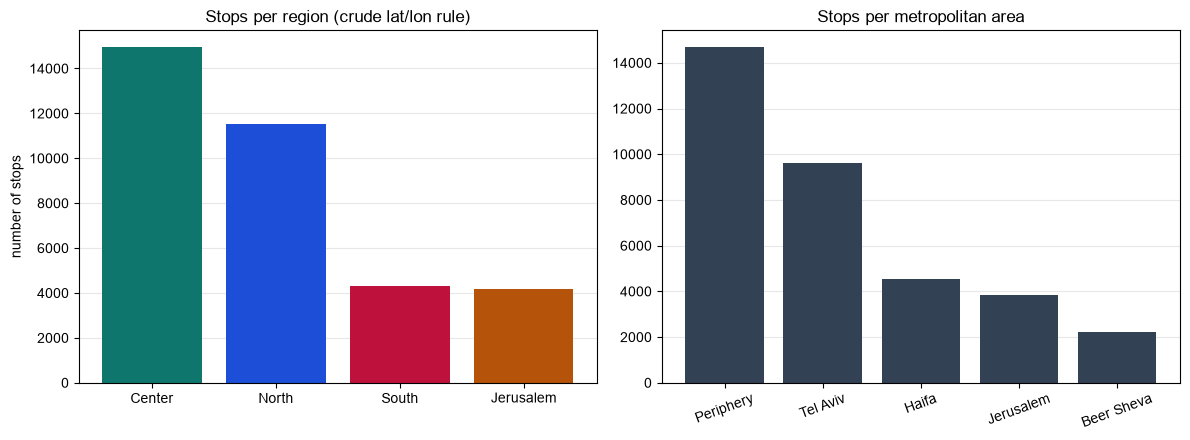

In [35]:
REGION_COLORS = {"North": "#1d4ed8", "Center": "#0f766e", "Jerusalem": "#b45309", "South": "#be123c"}

# --- Figure 1: stops per region and per metro ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
region_counts = stops["region"].value_counts()
axes[0].bar(region_counts.index, region_counts.values,
            color=[REGION_COLORS.get(r, "#64748b") for r in region_counts.index])
axes[0].set_title("Stops per region (crude lat/lon rule)")
axes[0].set_ylabel("number of stops")
metro_counts = stops["metro"].value_counts()
axes[1].bar(metro_counts.index, metro_counts.values, color="#334155")
axes[1].set_title("Stops per metropolitan area")
axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "region_and_metro_counts.png", dpi=150)
plt.show()

### Figure 2 - the map

This is the single strongest sanity check in the notebook. Plotting all the cleaned stops in longitude/latitude space should reproduce the recognizable shape of the country: a dense coastal strip, the Jerusalem corridor, and a thin scatter running down the Negev to Eilat. Anything that survived the bounding-box filter and is still wrong - a coordinate in the sea, a mirrored latitude - shows up here as a glaring outlier. Coloring by `region` simultaneously illustrates the crude latitude cuts, so the reader can see for themselves where the rule is arbitrary. The metro centers are marked so the disk radii can be judged by eye.

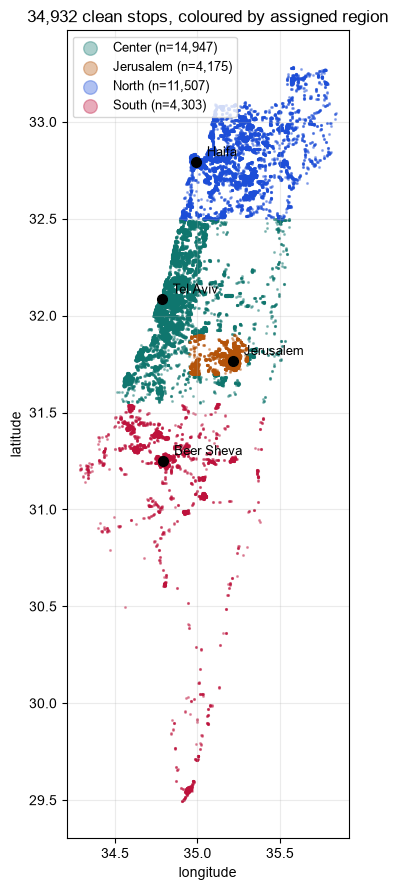

In [36]:
# --- Figure 2: every clean stop on the map, coloured by region ---
fig, ax = plt.subplots(figsize=(6.5, 9))
for name, part in stops.groupby("region"):
    ax.scatter(part["stop_lon"], part["stop_lat"], s=1.5, alpha=0.35,
               color=REGION_COLORS.get(name, "#64748b"),
               label=f"{name} (n={len(part):,d})")
for city, (clat, clon, radius) in METRO_CENTERS.items():
    ax.plot(clon, clat, marker="o", markersize=7, color="black", zorder=5)
    ax.annotate(city, (clon, clat), textcoords="offset points", xytext=(8, 4), fontsize=9, zorder=6)
ax.set_aspect(1.0 / math.cos(math.radians(31.7)))  # keep the country from looking stretched
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"{len(stops):,d} clean stops, coloured by assigned region")
ax.legend(markerscale=8, loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "stops_map_by_region.png", dpi=150)
plt.show()

### Figure 3 - service composition by mode

Routes and scheduled trips side by side, by GTFS `route_type`. The y axis is logarithmic because bus service is several orders of magnitude larger than any other mode; on a linear axis the rail and light-rail bars would be invisible. The gap between the two bars for the same mode is information in itself: a mode with few routes but many trips runs high-frequency service on a small network.

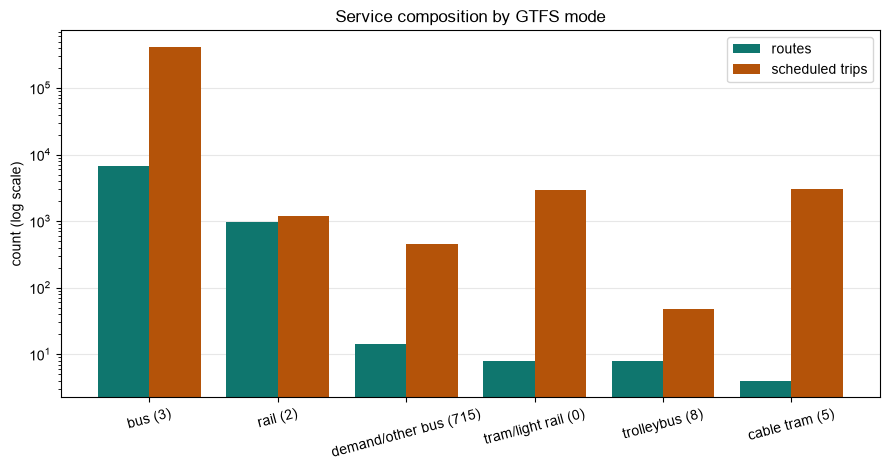

In [37]:
# --- Figure 3: routes and scheduled trips per GTFS mode (log scale) ---
labels = route_types["route_type_label"] + " (" + route_types["route_type"] + ")"
x = np.arange(len(route_types))
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - 0.2, route_types["routes"], width=0.4, label="routes", color="#0f766e")
ax.bar(x + 0.2, route_types["scheduled_trips"], width=0.4, label="scheduled trips", color="#b45309")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title("Service composition by GTFS mode")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "route_type_distribution.png", dpi=150)
plt.show()

### Figure 4 - operators

Scheduled trips per operator, top 12. This is a concentration check: Israel's public transport is run by many licensed operators, but service volume is expected to be dominated by a handful of them. The operator names are in Hebrew and shown through the bidi patch installed earlier - if reversed text appears in this figure, it's a sign the patch didn't take effect.

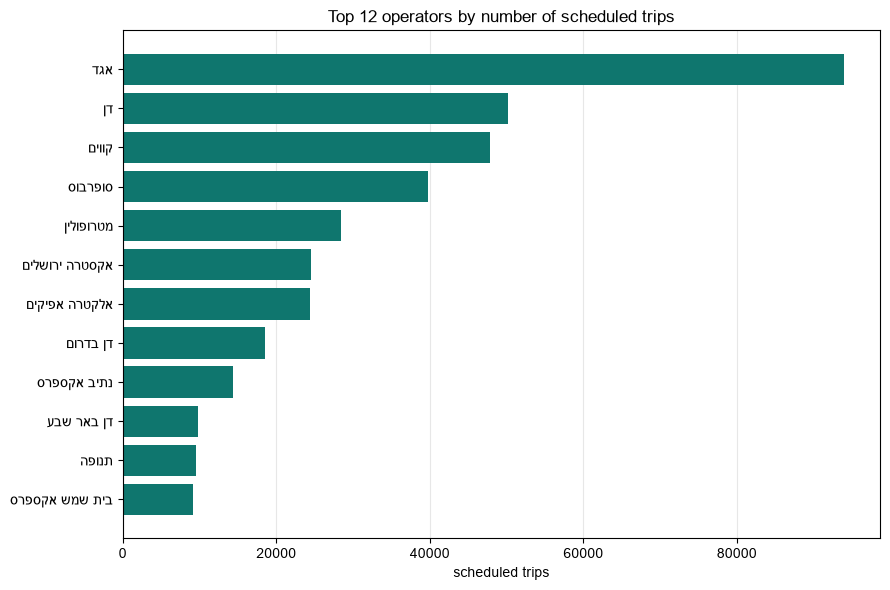

In [38]:
# --- Figure 4: top operators by scheduled trips (Hebrew names via the bidi patch) ---
top_agencies = agency_summary.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_agencies["agency_name"], top_agencies["scheduled_trips"], color="#0f766e")
ax.set_xlabel("scheduled trips")
ax.set_title("Top 12 operators by number of scheduled trips")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "top_agencies_by_trips.png", dpi=150)
plt.show()

## Saving the stage's outputs

Everything the later notebooks need is written into `outputs/nb/01_data_preparation/tables/`. The four `*_clean.csv` files are written with `utf-8-sig` so the Hebrew names open properly in Excel, and with `index=False` so re-reading them doesn't add a ghost column.

The JSON report is the output that makes this stage auditable: it stores the row counts for each filter, the bounding box actually used, the region and metro definitions, the breakdowns by mode and by location type, and the referential-integrity counts. A reviewer can read the report alone and know exactly what was removed and why, without re-running the notebook.

One small technical point: `Series.value_counts().to_dict()` may return NumPy integer values, which `json.dump` refuses to serialize in some pandas/NumPy combinations. The helper function below converts keys to `str` and values to plain `int`, so the report always serializes.

Writing `trips_clean.csv` (about 28 MB) is the slow part; set `SAVE_TRIPS_CSV = False` in the constants cell to skip it.

In [39]:
def counts_to_dict(series):
    """value_counts as a JSON-safe {str: int} dictionary."""
    return {str(k): int(v) for k, v in series.value_counts().items()}

# --- cleaned tables ---
stops.to_csv(TABLES / "stops_clean.csv", index=False, encoding="utf-8-sig")
routes.to_csv(TABLES / "routes_clean.csv", index=False, encoding="utf-8-sig")
agencies.to_csv(TABLES / "agencies_clean.csv", index=False, encoding="utf-8-sig")
if SAVE_TRIPS_CSV:
    trips.to_csv(TABLES / "trips_clean.csv", index=False, encoding="utf-8-sig")
else:
    print("skipped trips_clean.csv (SAVE_TRIPS_CSV = False)")

# --- derived summary tables ---
route_types.to_csv(TABLES / "route_type_distribution.csv", index=False, encoding="utf-8-sig")
agency_summary.to_csv(TABLES / "agency_trip_counts.csv", index=False, encoding="utf-8-sig")

# --- the audit trail ---
report = {
    "generated_by": "notebooks/01_data_preparation.ipynb",
    "gtfs_source_dir": str(DATA),
    "stops_raw": int(len(raw["stops"])),
    "stops_clean": int(len(stops)),
    "stops_dropped": int(len(raw["stops"]) - len(stops)),
    "routes_total": int(len(routes)),
    "trips_total": int(len(trips)),
    "agencies_total": int(len(agencies)),
    "cleaning_steps": cleaning_steps,
    "coordinate_bounds": {
        "lat_min": LAT_MIN, "lat_max": LAT_MAX,
        "lon_min": LON_MIN, "lon_max": LON_MAX,
    },
    "observed_bounds": {
        "lat_min": float(stops["stop_lat"].min()), "lat_max": float(stops["stop_lat"].max()),
        "lon_min": float(stops["stop_lon"].min()), "lon_max": float(stops["stop_lon"].max()),
    },
    "region_rule": (
        "crude first-match lat/lon rule: Jerusalem box (31.70-31.90 lat, 34.95-35.30 lon); "
        "North lat > 32.50; Center lat >= 31.55; South otherwise. Not an administrative geography."
    ),
    "metro_centers": {
        city: {"lat": c[0], "lon": c[1], "radius_km": c[2]} for city, c in METRO_CENTERS.items()
    },
    "region_counts": counts_to_dict(stops["region"]),
    "metro_counts": counts_to_dict(stops["metro"]),
    "location_type_counts": counts_to_dict(stops["location_type"]),
    "route_type_counts": counts_to_dict(routes["route_type"]),
    "integrity": {
        "trips_with_unknown_route_id": orphan_trips,
        "routes_with_unknown_agency_id": orphan_routes,
    },
}

report_path = TABLES / "data_cleaning_report.json"
with open(report_path, "w", encoding="utf-8") as fh:
    json.dump(report, fh, ensure_ascii=False, indent=2)

print("written to", TABLES)
for p in sorted(TABLES.iterdir()):
    print(f"  {p.name:32s} {p.stat().st_size / 1024**2:8.2f} MB")
print()
print(json.dumps({k: v for k, v in report.items() if k != "cleaning_steps"},
                 ensure_ascii=False, indent=2)[:2000])

written to C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\01_data_preparation\tables
  agencies_clean.csv                   0.00 MB
  agency_trip_counts.csv               0.00 MB
  data_cleaning_report.json            0.00 MB
  route_type_distribution.csv          0.00 MB
  routes_clean.csv                     0.94 MB
  stops_clean.csv                      5.27 MB
  trips_clean.csv                     27.47 MB

{
  "generated_by": "notebooks/01_data_preparation.ipynb",
  "gtfs_source_dir": "C:\\Users\\Sean-PC\\Desktop\\LAST SEMESTER\\אלגוריתמים ברשתות\\פרויקט גמר\\israel-public-transportation",
  "stops_raw": 34932,
  "stops_clean": 34932,
  "stops_dropped": 0,
  "routes_total": 7792,
  "trips_total": 420133,
  "agencies_total": 37,
  "coordinate_bounds": {
    "lat_min": 29.0,
    "lat_max": 34.0,
    "lon_min": 34.0,
    "lon_max": 36.0
  },
  "observed_bounds": {
    "lat_min": 29.493109,
    "lat_max": 33.282204,
    "lon_min": 34.284672,
    "lon_ma

## Conclusions

- **The file is clean.** All four cleaning filters - unparseable coordinates, latitude range, longitude range, and duplicate `stop_id` - remove **zero** rows from the shipped version of the file: every stop has numeric coordinates, every coordinate falls inside Israel's bounding box (the observed spread is roughly 29.49-33.28 N, 34.28-35.84 E, comfortably inside the 29-34 / 34-36 guard box), and `stop_id` is already unique. That's a negative result for the cleaning stage and a positive one for the data: the network's node set is the full raw stops table. The filters stay in the pipeline as guardrails for future file refreshes, and the report proves they were checked, not assumed.
- **The stops table is large and heavily bus-skewed.** About 35,000 stops, of which only a few hundred are parent stations with `location_type = 1`; `route_type = 3` (bus) dominates by orders of magnitude in both route count and scheduled-trip count. Any conclusion about "Israel's public-transport network" drawn from the full graph is really a conclusion about the bus network, which is why the project also analyzes the rail layer separately.
- **The region and metro labels are convenience labels, not geography.** The region is three latitude cuts plus one rectangle around Jerusalem; the metro is four circles with hand-picked radii. They're useful for coarse grouping and coloring maps, and should not be cited as regional statistics. The two labels are computed independently, and the cross-tab printed above shows where they disagree. The only structural guarantee is that the four metro disks are pairwise disjoint, so "first match wins" is equivalent to "nearest center wins" and the order introduces no bias.
- **Referential integrity was verified, not assumed.** The counts of trips with an unknown `route_id` and routes with an unknown `agency_id` are computed and stored in the report; later notebooks join these tables freely and rely on those counts being zero.
- **What was deliberately left for stage 02:** no edges exist yet. Nothing here reads `stop_times.txt`, so no notion of adjacency, headway, or travel time has been introduced yet. Merging parent/child stations was also deliberately left untouched, so the graph-building notebook can make that decision with the full stops table in front of it.